# USPTO Patent Explorations

In [13]:
# load libraries 
import pandas as pd 
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import numpy as np
import pyarrow.parquet as pypq
import textwrap 
from time import time 
import plotly.io as pio

tqdm.pandas()
plt.rcParams.update({'font.size': 22})
sns.set(style="ticks", context="talk")
plt.style.use("dark_background")
pd.options.plotting.backend = 'plotly'
pio.templates.default = 'plotly_dark+presentation'

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
# some helper functions 
def read_parquet(path, engine='pyarrow', columns=None, convert_dtypes=True, **args):
    """
    Read a parquet file (or a directory of parquet files) 
    columns: list of columns to read, by default, read all columns
    convert_dtypes: if True, convert datatypes to save RAM (takes extra time)
    """
    name = path.stem 
    column_st = 'columns="all"' if columns is None else f'{columns=!r}'
    print(f'\nReading {column_st} from {path!r} using {engine=!r}.')

    tic = time()
    df = pd.read_parquet(path, engine=engine, columns=columns, **args)
    toc = time()
    print(f'Read {len(df):,} rows from {path.stem!r} in {toc-tic:.2f} sec.')
    
    if convert_dtypes:
        tic = time()
        size_before = df.memory_usage(deep=True).sum() / 1024 / 1024 / 1024

        string_cols_d = {}
        for col, dtype in df.dtypes.to_dict().items():
            if dtype == 'object':  # convert object columns to string
                string_cols_d[col] = 'string[python]'
            if col == 'type' or col == 'concept_name':
                if dtype != 'category':
                    string_cols_d[col] = 'category'
            if col == 'publication_month':
                if dtype != 'uint8':
                    string_cols_d[col] = 'uint8'
            if col == 'score':
                if dtype != 'float16':
                    string_cols_d[col] = 'float16'
        # print(f'{string_cols_d=}')
        df = df.astype(string_cols_d) 
        
        size_after = df.memory_usage(deep=True).sum() / 1024 / 1024 / 1024
        toc = time()
        print(f'Converting dtypes took {toc-tic:.2f} sec. Size before: {size_before:.2f}GB, after: {size_after:.2f}GB.')
    
    display('Top 3 rows:', df.head(3))
    return df


def peek_parquet(path):
    """
    peeks at a parquet file (or a directory containing parquet files) without reading the whole thing and prints the following:
    * Path
    * schema
    * number of pieces (fragments)
    * number of rows 
    """
    parq_file = pypq.ParquetDataset(path)
    piece_count = len(parq_file.fragments)
    schema = textwrap.indent(parq_file.schema.to_string(), ' '*4)
    row_count = sum(frag.count_rows() for frag in parq_file.fragments)
    if Path(path).is_dir():
      size = sum(Path(frag.path).stat().st_size for frag in parq_file.fragments)
    else:
      size = path.stat().st_size
    
    st = [
        f'Name: {path.stem!r}',  
        f'Path: {str(path)!r}',
        f'Size: {size/1024/1024/1024:.2g} GB',
        f'Files: {piece_count:,}',
        f'Rows: {row_count:,}',
        f'Schema:\n{schema}',
        f'5 random rows:',
    ]
    print('\n'.join(st))
    sample_df = parq_file.fragments[0].head(5).to_pandas()  # read 5 rows from the first fragment
    display(sample_df)

    return

def read_smaller_tables(name):
    """
    Some smaller tables exist as a CSV only
    """
    assert name in ['institutions', 'institutions_geo', 'concepts']
    path = basepath / 'csv-files'/ month / name
    df = pd.read_csv(f'{path}.csv.gz', engine='c')
    return df

In [5]:
parq_path = Path('/data/shared/SciSciNet/')

In [9]:
peek_parquet(parq_path / 'sciscinet_link_patents.parquet')

Name: 'sciscinet_link_patents'
Path: '/data/shared/SciSciNet/sciscinet_link_patents.parquet'
Size: 0.31 GB
Files: 1
Rows: 47,844,586
Schema:
    paperid: large_string
    patent: large_string
    uspto: int64
5 random rows:


,paperid,patent,uspto
0,W1552,us-11426570-b2,1
1,W1552,us-11666239-b2,1
2,W1552,us-11678989-b2,1
3,W1552,us-11745001-b2,1
4,W1552,us-11826495-b2,1


In [25]:
patents_df = pd.read_csv('g_patent.tsv', nrows=50_000_000, sep='\t')
patents_df

/tmp/ipykernel_1161581/1647563883.py:1: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature de...,B2,20,0,ipg180619.xml
1,10000001,utility,2018-06-19,Injection molding machine and mold thickness c...,B2,12,0,ipg180619.xml
2,10000002,utility,2018-06-19,Method for manufacturing polymer film and co-e...,B2,9,0,ipg180619.xml
3,10000003,utility,2018-06-19,Method for producing a container from a thermo...,B2,18,0,ipg180619.xml
4,10000004,utility,2018-06-19,"Process of obtaining a double-oriented film, c...",B2,6,0,ipg180619.xml
...,...,...,...,...,...,...,...,...
9361439,T998013,defensive publication,1980-09-02,Protection of insect pheromones from degradati...,I4,1,0,pftaps19800902_wk36.zip
9361440,T998014,defensive publication,1980-09-02,"Thiazolyl couplers, coupler compositions and p...",I4,3,0,pftaps19800902_wk36.zip
9361441,T999001,defensive publication,1980-10-07,Sack handling device,I4,1,0,pftaps19801007_wk41.zip
9361442,T999002,defensive publication,1980-10-07,Application of polymeric powders to a substrate,I4,7,0,pftaps19801007_wk41.zip


In [27]:
patents_df.head()

,patent_id,patent_type,patent_date,patent_title,wipo_kind,num_claims,withdrawn,filename
0,10000000,utility,2018-06-19,Coherent LADAR using intra-pixel quadrature de...,B2,20,0,ipg180619.xml
1,10000001,utility,2018-06-19,Injection molding machine and mold thickness c...,B2,12,0,ipg180619.xml
2,10000002,utility,2018-06-19,Method for manufacturing polymer film and co-e...,B2,9,0,ipg180619.xml
3,10000003,utility,2018-06-19,Method for producing a container from a thermo...,B2,18,0,ipg180619.xml
4,10000004,utility,2018-06-19,"Process of obtaining a double-oriented film, c...",B2,6,0,ipg180619.xml


In [20]:
(
  patents_df
  .patent_type
  .value_counts()
)

patent_type
utility    4999932
reissue         49
design          15
TVPP             3
plant            1
Name: count, dtype: int64

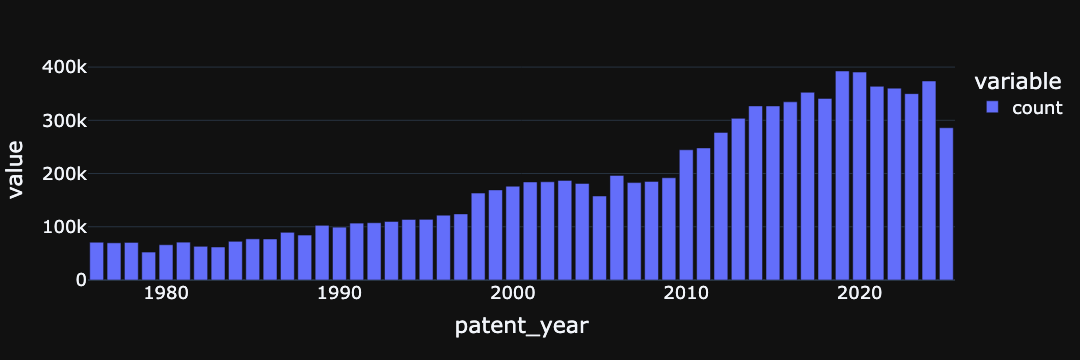

In [26]:
(
  patents_df
  .assign(
    patent_date=lambda df_: pd.to_datetime(df_.patent_date),
    patent_year=lambda df_: df_.patent_date.dt.year,
  )
  .patent_year
  .value_counts()
  .sort_index()
  .plot
  .bar()
)